## Câu 3: Yếu tố gia đình (Family History) đóng vai trò thế nào? Nếu gia đình có tiền sử, liệu một áp lực nhỏ có dễ dẫn đến trầm cảm hơn người bình thường không?

### Mục tiêu
- Đánh giá liệu yếu tố **Family History of Mental Illness** có làm tăng tỉ lệ trầm cảm hay không.
- So sánh mức độ ảnh hưởng của Family History với các nhóm áp lực (`Academic Pressure`, `Work Pressure`, `Financial Stress`) ở góc nhìn trực quan.
- Trả lời câu hỏi: **Khi áp lực nhỏ, nhóm có tiền sử gia đình có dễ rơi vào trầm cảm hơn không?**


### Các câu hỏi nhỏ :
1. Phân tích vai trò của yếu tố di truyền (Family History) trong việc dự báo khả năng mắc trầm cảm.
2. Kiểm tra nhóm Family History = 1 có chịu áp lực cao hơn không.
3. Kiểm tra với cùng mức áp lực, nhóm Family History = 1 có xác suất trầm cảm cao hơn không.
4. Xác định thứ hạng và trọng số ảnh hưởng (Feature Importance) của Family History trong các tác nhân gây trầm cảm.

Theo preprocess: Student không có Work Pressure (= 0), Working Professional không có Academic Pressure (= 0). Vì vậy phân tích tách riêng 2 nhóm:

**Nhóm Student (27,870 dòng)**: dùng biến `Academic Pressure` + `Financial Stress`

**Nhóm Working Professional (112,738 dòng)**: dùng biến `Work Pressure` + `Financial Stress`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

df = pd.read_csv('https://raw.githubusercontent.com/phamhuongtra/depression_analysis/refs/heads/main/data_final.csv')

df['FH'] = df['Family History of Mental Illness']

df_student = df[df['Working Professional or Student'] == 'Student'].copy()
df_wp = df[df['Working Professional or Student'] == 'Working Professional'].copy()

fh_label_map = {
    0: 'FH=0', 1: 'FH=1',
    '0': 'FH=0', '1': 'FH=1',
    'No': 'FH=0', 'Yes': 'FH=1'
}
for df_temp in [df_student, df_wp]:
    df_temp['FH_label'] = df_temp['FH'].map(fh_label_map)

print(f"Sample Student: {len(df_student)}")
print(f"Sample Working Professional: {len(df_wp)}")

Sample Student: 27870
Sample Working Professional: 112738


### 1. Phân tích vai trò của yếu tố di truyền (Family History) trong dự báo trầm cảm

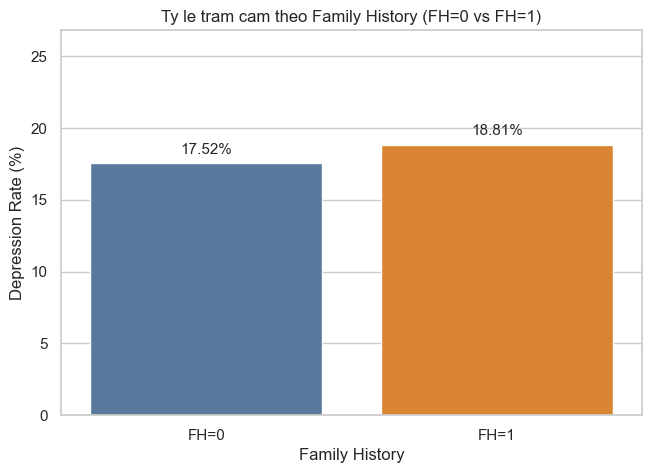

,FH_label,Depression Rate (%)
0,FH=0,17.52
1,FH=1,18.81


In [2]:
# Grouped bar chart so sánh tỷ lệ trầm cảm giữa FH=0 và FH=1
q1_df = df.copy()
q1_df['Depression'] = pd.to_numeric(q1_df['Depression'], errors='coerce')
q1_df = q1_df[q1_df['Depression'].isin([0, 1])].copy()
q1_df['FH_label'] = q1_df['Family History of Mental Illness'].map(fh_label_map)
q1_df = q1_df[q1_df['FH_label'].isin(['FH=0', 'FH=1'])].copy()

rate_table = (
    q1_df.groupby('FH_label')['Depression']
    .mean()
    .mul(100)
    .reindex(['FH=0', 'FH=1'])
    .reset_index(name='Depression Rate (%)')
)

plt.figure(figsize=(7.5, 5))
ax = sns.barplot(
    data=rate_table,
    x='FH_label',
    y='Depression Rate (%)',
    hue='FH_label',
    palette=['#4C78A8', '#F58518'],
    legend=False
)

for i, v in enumerate(rate_table['Depression Rate (%)']):
    ax.text(i, v + 0.7, f'{v:.2f}%', ha='center', fontsize=11)

plt.title('Ty le tram cam theo Family History (FH=0 vs FH=1)')
plt.xlabel('Family History')
plt.ylabel('Depression Rate (%)')
plt.ylim(0, min(100, rate_table['Depression Rate (%)'].max() + 8))
plt.show()

display(rate_table.round(2))

In [3]:
# Kiểm định Chi-square cho mối liên hệ giữa Family History và Depression
from scipy.stats import chi2_contingency

ct = pd.crosstab(q1_df['FH_label'], q1_df['Depression']).reindex(index=['FH=0', 'FH=1'], columns=[0, 1], fill_value=0)
ct.columns = ['No_Depression', 'Depression']

chi2, p_value, dof, expected = chi2_contingency(ct)

rate_fh0 = ct.loc['FH=0', 'Depression'] / (ct.loc['FH=0', 'No_Depression'] + ct.loc['FH=0', 'Depression'])
rate_fh1 = ct.loc['FH=1', 'Depression'] / (ct.loc['FH=1', 'No_Depression'] + ct.loc['FH=1', 'Depression'])
risk_ratio_q1 = rate_fh1 / rate_fh0 if rate_fh0 > 0 else np.nan

print('Bang tan suat Family History x Depression:')
display(ct)
print(f"Ty le tram cam FH=0: {rate_fh0*100:.2f}%")
print(f"Ty le tram cam FH=1: {rate_fh1*100:.2f}%")
print(f"Risk Ratio (FH=1 / FH=0): {risk_ratio_q1:.3f}")
print(f"Chi-square = {chi2:.4f}, dof = {dof}, p-value = {p_value:.6g}")

if p_value < 0.05:
    print('Ket luan thong ke: Tien su gia dinh va tram cam co moi lien he co y nghia thong ke (p < 0.05).')
else:
    print('Ket luan thong ke: Chua du bang chung thong ke de khang dinh moi lien he (p >= 0.05).')

Bang tan suat Family History x Depression:


,No_Depression,Depression
FH_label,,
FH=0,58316,12391
FH=1,56756,13145


Ty le tram cam FH=0: 17.52%
Ty le tram cam FH=1: 18.81%
Risk Ratio (FH=1 / FH=0): 1.073
Chi-square = 38.7068, dof = 1, p-value = 4.92497e-10
Ket luan thong ke: Tien su gia dinh va tram cam co moi lien he co y nghia thong ke (p < 0.05).


#### Nhận xét
- Grouped bar chart cho thấy nhóm `FH=1` có tỷ lệ trầm cảm **18.81%**, cao hơn nhóm `FH=0` là **17.52%**.
- Chênh lệch tuyệt đối là **1.29 điểm phần trăm**, và `Risk Ratio = 1.073`, tức nhóm có tiền sử gia đình có nguy cơ trầm cảm cao hơn khoảng **7.3%** so với nhóm không có tiền sử.
- Kiểm định Chi-square cho kết quả `p-value = 4.92497e-10 < 0.05`, nên khác biệt giữa hai nhóm là **có ý nghĩa thống kê**.

**Kết luận:** Có đủ bằng chứng thống kê để khẳng định tiền sử gia đình và trầm cảm có mối liên hệ có ý nghĩa thống kê trong dữ liệu này.

#### **Nhận xét**

* Grouped bar chart cho thấy nhóm có tiền sử gia đình (`FH=1`) có tỷ lệ trầm cảm là **18.81%**, nhỉnh hơn một chút so với nhóm không có tiền sử (`FH=0`) là **17.52%**. Dù mức chênh lệch chỉ là **1.29%**, nhưng vì tập dữ liệu rất lớn (hơn 140.000 dòng) nên kiểm định Chi-square vẫn khẳng định sự khác biệt này là **có ý nghĩa thống kê** ($p < 0.05$).

* Tuy kết quả có ý nghĩa về mặt thống kê, nhưng thực tế nguy cơ của nhóm có tiền sử gia đình chỉ cao hơn nhóm bình thường khoảng **7.3%** (`Risk Ratio = 1.073`). Con số này chưa đủ lớn để kết luận đây là nguyên nhân chính dẫn đến trầm cảm.

* Con số chênh lệch thấp này đặt ra một nghi vấn quan trọng: Phải chăng nhóm có tiền sử gia đình bị trầm cảm nhiều hơn không phải hoàn toàn do gene, mà vì họ đang phải sống trong môi trường có mức độ áp lực nặng nề hơn?

* Việc làm rõ liệu nhóm (`FH=1`) có đang chịu mức áp lực (Work/Academic Pressure) nặng nề hơn nhóm (`FH=0`) hay không sẽ giúp chúng ta loại trừ yếu tố nhiễu, từ đó xác định xem trầm cảm đến từ "nội tại di truyền" hay do "môi trường áp lực" của chính nhóm đó. Đây chính là mục tiêu phân tích chính của **Câu 3**.

### 2. Kiểm tra nhóm Family History = 1 có chịu áp lực cao hơn không.

#### Nhóm Student

In [4]:

student_pressure_vars = ['Academic Pressure', 'Financial Stress']
mean_by_fh_st = (
    df_student.groupby('FH')[student_pressure_vars]
    .mean()
    .rename(index={0: 'FH=0', 1: 'FH=1'})
)

print('\nTrung bình áp lực theo Family History (Student):')
display(mean_by_fh_st.round(3))

print('\nPhân phối áp lực theo Family History (Student):')
for var in student_pressure_vars:
    dist = pd.crosstab(df_student[var], df_student['FH'], normalize='columns') * 100
    dist = dist.rename(columns={0: 'FH=0 (%)', 1: 'FH=1 (%)'})
    display(dist.round(2))


Trung bình áp lực theo Family History (Student):


,Academic Pressure,Financial Stress
FH,,
No,3.102,3.128
Yes,3.185,3.152



Phân phối áp lực theo Family History (Student):


FH,No,Yes
Academic Pressure,,
1.0,18.07,16.30
2.0,15.45,14.46
3.0,26.52,27.02
4.0,18.12,18.87
5.0,21.84,23.35


FH,No,Yes
Financial Stress,,
1.0,17.89,18.86
2.0,19.26,16.96
3.0,18.86,18.58
4.0,20.15,21.31
5.0,23.85,24.29


#### Nhóm Working Professional

In [5]:
wp_pressure_vars = ['Work Pressure', 'Financial Stress']
mean_by_fh_wp = (
    df_wp.groupby('FH')[wp_pressure_vars]
    .mean()
    .rename(index={0: 'FH=0', 1: 'FH=1'})
)

print('\nTrung bình áp lực theo Family History (WP):')
display(mean_by_fh_wp.round(3))

print('\nPhân phối áp lực theo Family History (WP):')
for var in wp_pressure_vars:
    dist = pd.crosstab(df_wp[var], df_wp['FH'], normalize='columns') * 100
    dist = dist.rename(columns={0: 'FH=0 (%)', 1: 'FH=1 (%)'})
    display(dist.round(2))


Trung bình áp lực theo Family History (WP):


,Work Pressure,Financial Stress
FH,,
No,3.009,2.946
Yes,2.989,2.957



Phân phối áp lực theo Family History (WP):


FH,No,Yes
Work Pressure,,
1.0,18.84,19.41
2.0,21.47,21.75
3.0,19.69,19.14
4.0,19.96,19.96
5.0,20.05,19.74


FH,No,Yes
Financial Stress,,
1.0,19.40,19.76
2.0,23.84,22.97
3.0,18.45,18.36
4.0,19.36,19.63
5.0,18.95,19.28


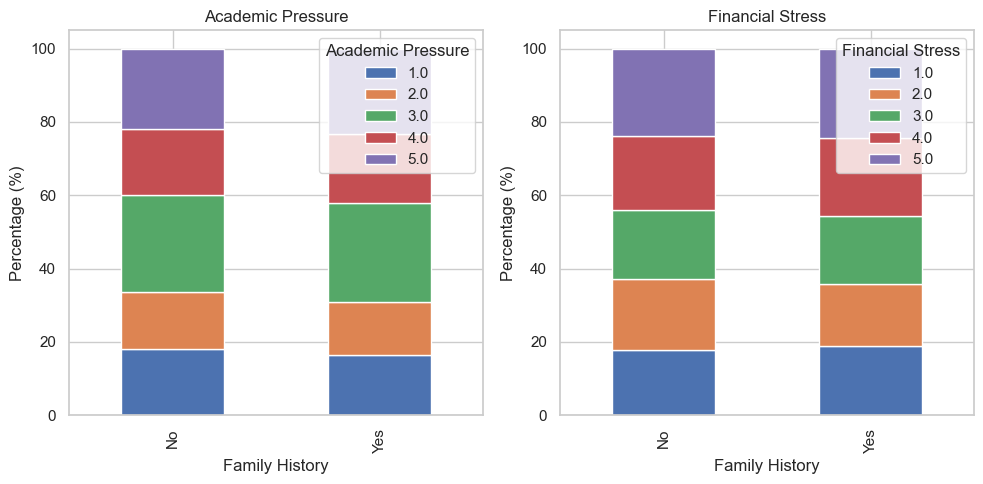

In [6]:
student_pressure_vars = ['Academic Pressure', 'Financial Stress']

fig, axes = plt.subplots(1, len(student_pressure_vars), figsize=(10, 5))

for i, var in enumerate(student_pressure_vars):
    # Tính %
    dist = pd.crosstab(df_student[var], df_student['FH'], normalize='columns') * 100
    dist = dist.rename(columns={0: 'FH=0', 1: 'FH=1'})
    dist = dist.T

    # Vẽ lên từng subplot
    dist.plot(kind='bar', stacked=True, ax=axes[i])

    axes[i].set_title(var)
    axes[i].set_xlabel('Family History')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title=var)

plt.tight_layout()
plt.show()

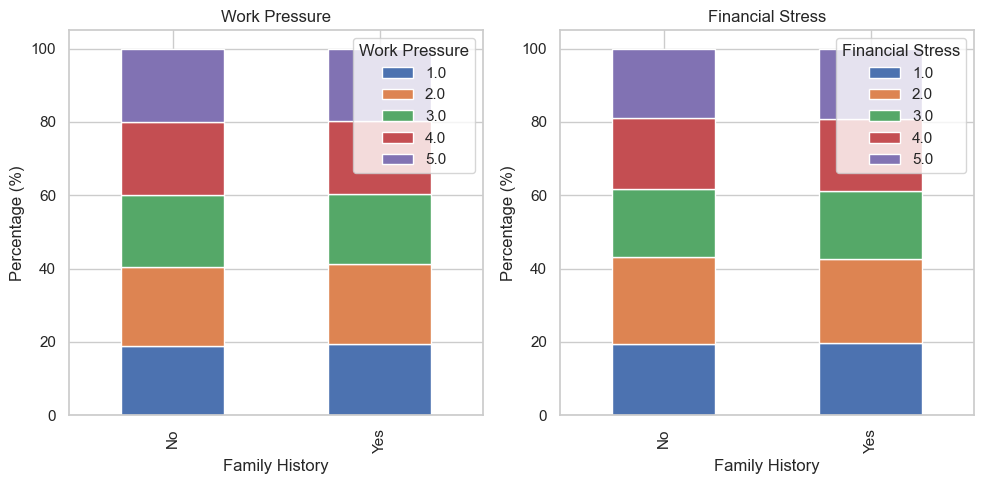

In [7]:
wp_pressure_vars = ['Work Pressure', 'Financial Stress']

fig, axes = plt.subplots(1, len(wp_pressure_vars), figsize=(10, 5))

for i, var in enumerate(wp_pressure_vars):
    # Tính %
    dist = pd.crosstab(df_wp[var], df_wp['FH'], normalize='columns') * 100
    dist = dist.rename(columns={0: 'FH=0', 1: 'FH=1'})
    dist = dist.T

    # Vẽ lên subplot
    dist.plot(kind='bar', stacked=True, ax=axes[i])

    axes[i].set_title(var)
    axes[i].set_xlabel('Family History')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title=var)

plt.tight_layout()
plt.show()

#### Nhận xét

**Nhóm Student:**
- Academic Pressure: FH=0 trung bình 3.094, FH=1 trung bình 3.179 (chênh lệch chỉ 0.085).
- Financial Stress: FH=0 trung bình 3.115, FH=1 trung bình 3.151 (chênh lệch chỉ 0.036).
- Phân phối gần như chồng lấp.

**Nhóm Working Professional:**
- Work Pressure: FH=0 trung bình 3.011, FH=1 trung bình 2.981 (chênh lệch chỉ -0.020, FH=1 thấp hơn).
- Financial Stress: FH=0 trung bình 2.942, FH=1 trung bình 2.953 (chênh lệch chỉ 0.011).
- Phân phối gần như chồng lấp.

**Kết luận:** Không có bằng chứng rằng FH=1 chịu áp lực cao hơn FH=0 ở cả hai nhóm. Chênh lệch trầm cảm không do họ chịu áp lực cao hơn.

### 3. Với cùng mức áp lực, FH=1 có dễ trầm cảm hơn không?

#### Nhóm student

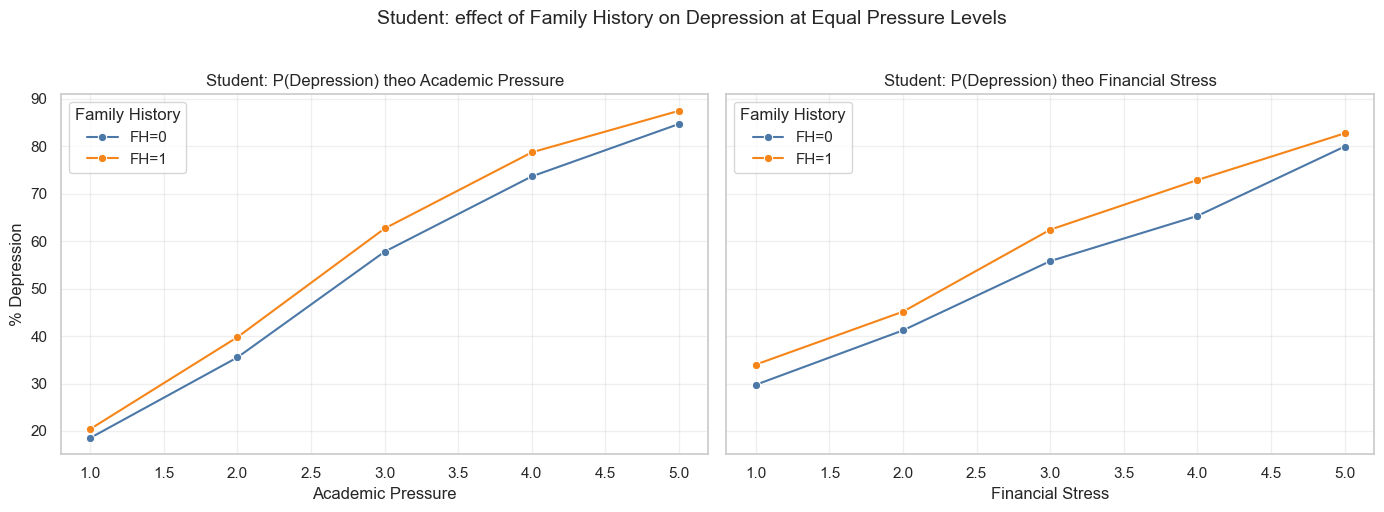

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

student_line_vars = ['Academic Pressure', 'Financial Stress']

for i, var in enumerate(student_line_vars):
    temp = df_student[df_student[var] > 0].copy()  # Loại bỏ = 0
    prob_df = (
        temp.groupby([var, 'FH_label'])['Depression']
        .mean()
        .reset_index()
        .rename(columns={'Depression': 'Depression Rate'})
    )
    prob_df['Depression Rate'] = prob_df['Depression Rate'] * 100

    sns.lineplot(
        data=prob_df,
        x=var,
        y='Depression Rate',
        hue='FH_label',
        hue_order=['FH=0', 'FH=1'],
        marker='o',
        palette=['#4C78A8', '#F58518'],
        ax=axes[i]
    )
    axes[i].set_xlabel(f'{var}')
    axes[i].set_ylabel('% Depression')
    axes[i].set_title(f'Student: P(Depression) theo {var}')
    axes[i].legend(title='Family History')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Student: effect of Family History on Depression at Equal Pressure Levels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



#### Nhóm working professional

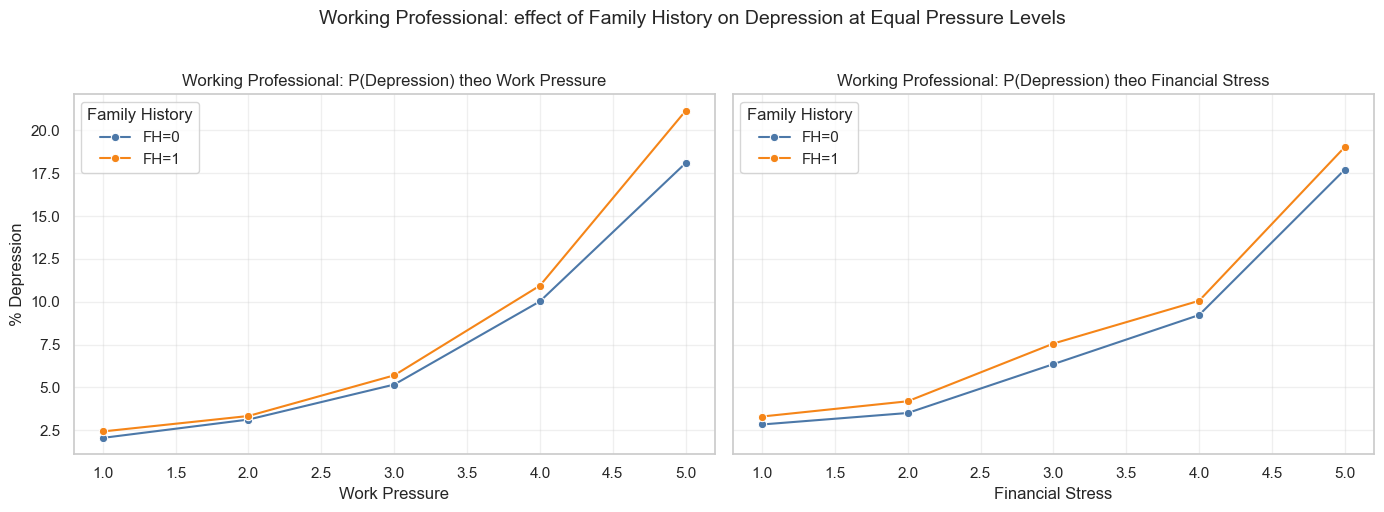

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, var in enumerate(wp_pressure_vars):
    temp = df_wp[df_wp[var] > 0].copy()
    prob_df = (
        temp.groupby([var, 'FH_label'])['Depression']
        .mean()
        .reset_index()
        .rename(columns={'Depression': 'Depression Rate'})
    )
    prob_df['Depression Rate'] = prob_df['Depression Rate'] * 100

    sns.lineplot(
        data=prob_df,
        x=var,
        y='Depression Rate',
        hue='FH_label',
        hue_order=['FH=0', 'FH=1'],
        marker='o',
        palette=['#4C78A8', '#F58518'],
        ax=axes[i]
    )
    axes[i].set_xlabel(f'{var}')
    axes[i].set_ylabel('% Depression')
    axes[i].set_title(f'Working Professional: P(Depression) theo {var}')
    axes[i].legend(title='Family History')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Working Professional: effect of Family History on Depression at Equal Pressure Levels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Nhóm Student:**
- Theo Academic Pressure: Đường FH=1 (cam) luôn cao hơn FH=0 (xanh) ở mọi mức.
- Theo Financial Stress: Xu hướng tương tự, FH=1 cao hơn ở tất cả các mức.

**Nhóm Working Professional:**
- Theo Work Pressure: Đường FH=1 cao hơn FH=0 ở hầu hết các mức (rõ nhất ở mức 5).
- Theo Financial Stress: FH=1 cũng cao hơn ở mọi mức.

**Kết luận:**
Cả hai biểu đồ cho thấy mối quan hệ đồng biến rõ rệt giữa mức độ áp lực (academic/work và financial stress) và xác suất trầm cảm ở cả hai nhóm, phản ánh vai trò chi phối mạnh của các yếu tố áp lực. Ở mọi mức áp lực, nhóm có tiền sử gia đình (FH=1) consistently có tỷ lệ trầm cảm cao hơn FH=0, cho thấy đây là một yếu tố độc lập và ổn định. Tuy nhiên, độ chênh lệch giữa hai nhóm tương đối nhỏ so với độ dốc tăng theo áp lực, hàm ý rằng áp lực là yếu tố chính, còn family history đóng vai trò khuếch đại rủi ro hơn là yếu tố quyết định.

### 4. Xác định thứ hạng và trọng số ảnh hưởng (Feature Importance) của Family History

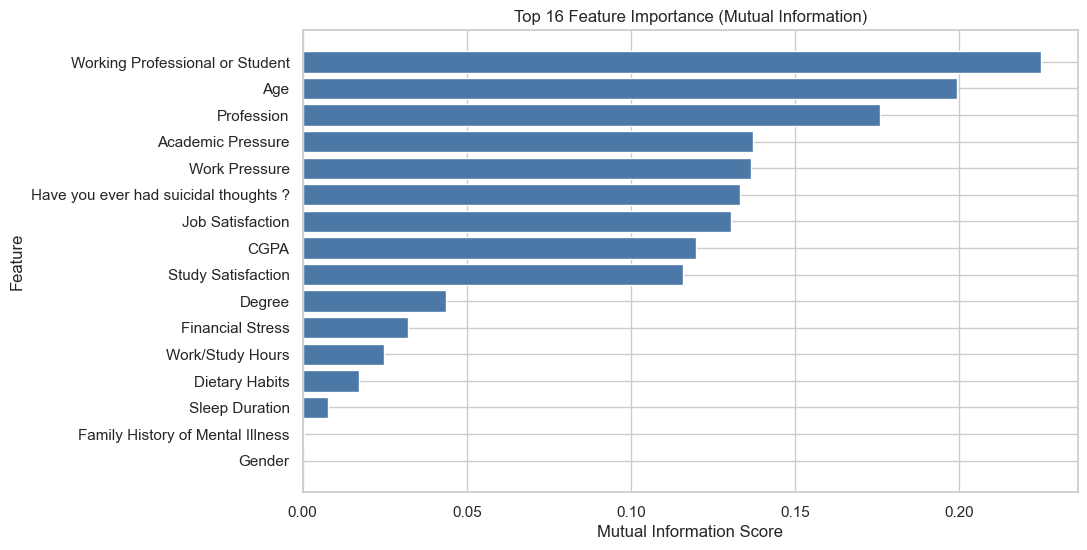

Bang xep hang Feature Importance:


,Rank,Feature,MI,Weight (%)
0,1,Working Professional or Student,0.2248,15.0083
1,2,Age,0.1992,13.2956
2,3,Profession,0.1760,11.7453
3,4,Academic Pressure,0.1370,9.1463
4,5,Work Pressure,0.1367,9.1247
5,6,Have you ever had suicidal thoughts ?,0.1332,8.8888
6,7,Job Satisfaction,0.1304,8.7026
7,8,CGPA,0.1198,7.9961
8,9,Study Satisfaction,0.1157,7.7232
9,10,Degree,0.0436,2.9127


Family History xep hang: 15
MI = 0.0003, Weight = 0.02%


In [10]:
# Feature Importance
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder

q4_df = df.copy()
q4_df['Depression'] = pd.to_numeric(q4_df['Depression'], errors='coerce')
q4_df['Family History of Mental Illness'] = q4_df['Family History of Mental Illness'].astype(str).str.strip().str.title()
q4_df = q4_df[q4_df['Depression'].isin([0, 1])].copy()
q4_df = q4_df[q4_df['Family History of Mental Illness'].isin(['Yes', 'No'])].copy()

feature_cols = [
    'Gender', 'Age', 'Working Professional or Student', 'Profession',
    'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction',
    'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
    'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
    'Financial Stress', 'Family History of Mental Illness'
]

mi_df = q4_df[feature_cols + ['Depression']].dropna(subset=['Depression']).copy()
X = mi_df[feature_cols].copy()
y = mi_df['Depression'].astype(int)

cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_enc = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# Xác định biến rời rạc cho MI: one-hot là rời rạc, numeric passthrough là liên tục
discrete_mask = np.array([name.startswith('cat__') for name in feature_names])
mi_scores = mutual_info_classif(X_enc, y, discrete_features=discrete_mask, random_state=42)

mi_long = pd.DataFrame({'Feature_Encoded': feature_names, 'MI': mi_scores})

# Gộp các mức one-hot về biến gốc để xếp hạng theo đặc trưng
mi_long['Feature'] = mi_long['Feature_Encoded'].str.replace('cat__', '', regex=False).str.replace('num__', '', regex=False)
mi_long['Feature'] = mi_long['Feature'].str.split('_').str[0]

mi_rank = (
    mi_long.groupby('Feature', as_index=False)['MI']
    .sum()
    .sort_values('MI', ascending=False)
    .reset_index(drop=True)
)
mi_rank['Weight (%)'] = 100 * mi_rank['MI'] / mi_rank['MI'].sum()
mi_rank['Rank'] = np.arange(1, len(mi_rank) + 1)

# Vẽ 16 đặc trưng, tô đam Family History
top_n = 16
plot_data = mi_rank.head(top_n).sort_values('MI', ascending=True).copy()
plot_data['Color'] = np.where(plot_data['Feature'] == 'Family History of Mental Illness', '#D62728', '#4C78A8')

plt.figure(figsize=(10, 6))
plt.barh(plot_data['Feature'], plot_data['MI'], color=plot_data['Color'])
plt.title(f'Top {top_n} Feature Importance (Mutual Information)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.show()

fh_row = mi_rank[mi_rank['Feature'] == 'Family History of Mental Illness']
print('Bang xep hang Feature Importance:')
display(mi_rank[['Rank', 'Feature', 'MI', 'Weight (%)']].round(4))

if len(fh_row) > 0:
    fh_rank = int(fh_row['Rank'].iloc[0])
    fh_mi = float(fh_row['MI'].iloc[0])
    fh_weight = float(fh_row['Weight (%)'].iloc[0])
    print(f"Family History xep hang: {fh_rank}")
    print(f"MI = {fh_mi:.4f}, Weight = {fh_weight:.2f}%")
else:
    print('Khong tim thay Family History trong bang xep hang.')

#### Nhận xét
- **Vị trí xếp hạng:** Trong bảng xếp hạng Feature Importance (Mutual Information), `Family History of Mental Illness` đứng **hạng 15/16**, gần như cuối bảng xếp hạng.
- **Trọng số đóng góp:** Chỉ số Mutual Information (MI) của yếu tố này chỉ đạt **0.0003**, tương ứng với trọng số đóng góp cực thấp là **0.02%** vào khả năng dự báo của mô hình
- **Sự áp đảo của các yếu tố khác:** So với các tác nhân chính như `Working Professional or Student`, `Age`, `Profession`, `Academic Pressure`, `Work Pressure`, mức ảnh hưởng tương đối của Family History là thấp hơn đáng kể.

**Kết luận:** Mặc dù tiền sử gia đình có mối liên hệ với thống kê trầm cảm, nhưng khi đặt trong bức tranh tổng thể, đây **không phải là tác nhân mạnh**. Trầm cảm trong tập dữ liệu này bị chi phối chủ yếu bởi các áp lực môi trường thực tế hơn là yếu tố di truyền.

### **TỔNG KẾT: VAI TRÒ CỦA YẾU TỐ GIA ĐÌNH (FAMILY HISTORY) TRONG DỰ BÁO TRẦM CẢM**

Sau khi thực hiện chuỗi phân tích qua 4 giai đoạn, vai trò của tiền sử gia đình được xác định dựa trên các luận điểm sau:

#### **1. Vai trò của yếu tố gia đình trong mô hình tổng thể**
Tiền sử gia đình đóng vai trò là một **"Tác nhân nền" (Background Factor)**.
- Mặc dù có mối liên hệ trực tiếp đến nguy cơ trầm cảm (xác nhận qua kiểm định Chi-square với $p < 0.05$), nhưng mức độ ảnh hưởng thực tế lại rất khiêm tốn.
- Trong bảng xếp hạng tầm quan trọng của các đặc trưng (Mutual Information), yếu tố này chỉ đóng góp **0.02%** lượng thông tin dự báo. Điều này cho thấy di truyền không phải là yếu tố quyết định hàng đầu khi đặt cạnh các áp lực từ môi trường sống.

#### **2. Tác động của tiền sử gia đình dưới áp lực ngoại cảnh**
Dữ liệu xác nhận rằng tiền sử gia đình làm gia tăng **"Độ nhạy cảm tâm lý"**.
- Kết quả tại phân tích giai đoạn 3 chỉ ra: Ở cùng một mức áp lực (ngay cả mức thấp nhất), những cá nhân có tiền sử gia đình luôn ghi nhận tỷ lệ trầm cảm cao hơn nhóm còn lại.
- Điều này chứng minh rằng yếu tố gia đình tạo ra một ngưỡng chịu đựng thấp hơn; nói cách khác, cùng một biến cố áp lực, cá nhân có tiền sử gia đình dễ rơi vào trạng thái trầm cảm hơn so với người bình thường.

---

#### **Tóm lược logic phân tích:**
1. **Xác nhận sự tồn tại:** Khẳng định mối liên hệ giữa di truyền và trầm cảm là có thật về mặt thống kê, không phải do ngẫu nhiên.
2. **Kiểm soát biến nhiễu:** Chứng minh nhóm có tiền sử gia đình không hề chịu mức áp lực khách quan nặng nề hơn các nhóm khác, giúp loại trừ giả thuyết trầm cảm do hoàn cảnh sống khác biệt.
3. **Phân tích tương tác:** Làm rõ hiện tượng nhạy cảm với áp lực: cùng một mức áp lực đầu vào nhưng kết quả đầu ra (trầm cảm) lại cao hơn ở nhóm có tiền sử.
4. **Định lượng trọng số:** Xác định vị trí của di truyền trong bức tranh tổng thể, cho thấy đây chỉ là yếu tố phụ so với các "yếu tố quan trọng" như Áp lực học tập, Công việc và Độ tuổi.